<a href="https://colab.research.google.com/github/ivymist/eple/blob/main/DLprac10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical 10**

**Denoising of images using autoencoder**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras import layers

In [ ]:
(xtrain, _), (xtest, _)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
xtrain=xtrain.astype('float32')/255.0
xtest=xtest.astype('float32')/255.0

xtrain=np.reshape(xtrain, (len(xtrain), 28, 28, 1))
xtest=np.reshape(xtest, (len(xtest), 28, 28, 1))

In [ ]:
noise_factor=0.5

xtrain_noisy=xtrain+noise_factor*np.random.normal(loc=0.0, scale=1.0, size=xtrain.shape)
xtest_noisy=xtest+noise_factor*np.random.normal(loc=0.0, scale=1.0, size=xtest.shape)

In [ ]:
xtrain_noisy=np.clip(xtrain_noisy, 0., 1.)
xtest_noisy=np.clip(xtest_noisy, 0., 1.)

In [ ]:
in_img=Input(shape=(28, 28, 1))

x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(in_img)
x=layers.MaxPooling2D((2, 2), padding='same')(x)
x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded=layers.MaxPooling2D((2, 2), padding='same')(x)

x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x=layers.UpSampling2D((2, 2))(x)
x=layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x=layers.UpSampling2D((2, 2))(x)
decoded=layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

In [ ]:
autoencoder=Model(in_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
autoencoder.fit(xtrain_noisy, xtrain, epochs=10, batch_size=128, shuffle=True, validation_data=(xtest_noisy, xtest))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.1677 - val_loss: 0.1168
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1134 - val_loss: 0.1082
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1076 - val_loss: 0.1048
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1050 - val_loss: 0.1029
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1031 - val_loss: 0.1017
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1018 - val_loss: 0.1002
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1007 - val_loss: 0.0995
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0997 - val_loss: 0.0984
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0989 - val_loss: 0.0978
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0983 - val_loss: 0.0975


In [ ]:
decoded_imgs=autoencoder.predict(xtest_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


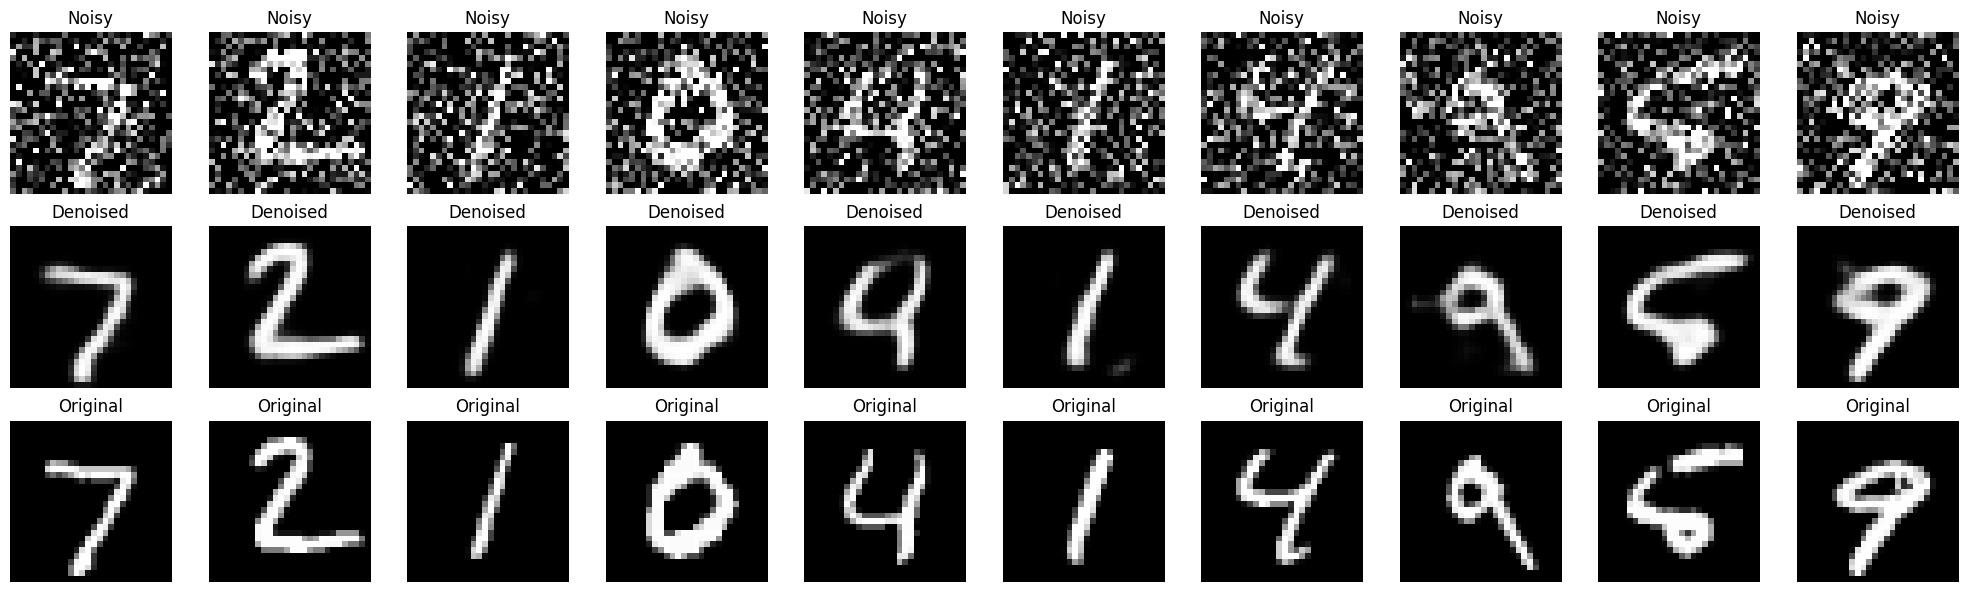

In [ ]:
n=10
plt.figure(figsize=(20, 6))

for i in range(n):
  ax=plt.subplot(3, n, i+1)
  plt.imshow(xtest_noisy[i].reshape(28, 28), cmap='gray')
  plt.title("Noisy")
  plt.axis("off")

  ax=plt.subplot(3, n, i+n+1)
  plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
  plt.title("Denoised")
  plt.axis("off")

  ax=plt.subplot(3, n, i+2*n+1)
  plt.imshow(xtest[i].reshape(28, 28), cmap='gray')
  plt.title("Original")
  plt.axis("off")
plt.tight_layout()
plt.show()